In [1]:
# 01. Imports
import warnings
import sys
import json
from datetime import date
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sqlalchemy import text
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else plt.style.use("ggplot")

In [2]:
# 02. Configuration
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path(".").resolve()
for p in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    if (p / "ETL").exists() or (p / "requirements.txt").exists():
        PROJECT_ROOT = p
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ETL.config import get_db_engine

N_CLUSTERS_RANGE = range(2, 9)
RFM_REFERENCE_DATE = date(2018, 9, 5)
STABILITY_SEEDS = [42, 100, 2024, 777, 999]

OUTPUT_BASE = PROJECT_ROOT / "NOTEBOOKS" / "06_customer_segmentation_outputs"
MODELS_DIR = OUTPUT_BASE / "models"
OUTPUTS_DIR = OUTPUT_BASE / "outputs"
FIGURES_DIR = OUTPUT_BASE / "figures"
METADATA_DIR = OUTPUT_BASE / "metadata"

for d in [MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [3]:
# 03. Database Connection
engine = get_db_engine()
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).scalar()
    print(f"Database engine connection test successful: result={result}")

Database engine connection test successful: result=1


In [4]:
# 04. SQL Data Extraction
SQL_QUERY = """
SELECT 
    c.customer_unique_id,
    COUNT(DISTINCT f.order_id) AS number_of_orders,
    SUM(f.total_sales_amount) AS total_revenue,
    AVG(f.total_sales_amount) AS average_order_value,
    SUM(f.quantity) AS total_items_purchased,
    COUNT(DISTINCT f.product_key) AS unique_products,
    COUNT(DISTINCT p.product_category_name_english) AS unique_categories,
    AVG(f.freight_value) AS avg_freight,
    MIN(d.full_date) AS first_purchase_date,
    MAX(d.full_date) AS last_purchase_date,
    COALESCE(MAX(g.state_code), 'UNKNOWN') AS customer_state
FROM fact_sales f
JOIN dim_customer c ON f.customer_key = c.customer_key
JOIN dim_date d ON f.purchase_date_key = d.date_key
JOIN dim_product p ON f.product_key = p.product_key
LEFT JOIN dim_geography g ON c.geography_key = g.geography_key
GROUP BY c.customer_unique_id;
"""
with engine.connect() as conn:
    pandas_raw = pd.read_sql(SQL_QUERY, conn)

print(f"Extracted aggregated SQL profile for {len(pandas_raw):,} unique customers.")

Extracted aggregated SQL profile for 95,420 unique customers.


In [5]:
# 05. Data Validation
df_raw = pl.from_pandas(pandas_raw).with_columns([
    pl.col("first_purchase_date").cast(pl.Date),
    pl.col("last_purchase_date").cast(pl.Date),
    pl.col("total_revenue").cast(pl.Float64),
    pl.col("average_order_value").cast(pl.Float64),
    pl.col("number_of_orders").cast(pl.Int64),
    pl.col("total_items_purchased").cast(pl.Int64),
    pl.col("unique_products").cast(pl.Int64),
    pl.col("unique_categories").cast(pl.Int64),
    pl.col("avg_freight").cast(pl.Float64),
])

print("Dataset Schema Validation:")
print(df_raw.schema)
print(f"Duplicate Customer Unique IDs: {df_raw.height - df_raw.select('customer_unique_id').n_unique()}")
print("\nSummary statistics:")
print(df_raw.select(["total_revenue", "number_of_orders", "average_order_value", "avg_freight"]).describe())

Dataset Schema Validation:
Schema({'customer_unique_id': String, 'number_of_orders': Int64, 'total_revenue': Float64, 'average_order_value': Float64, 'total_items_purchased': Int64, 'unique_products': Int64, 'unique_categories': Int64, 'avg_freight': Float64, 'first_purchase_date': Date, 'last_purchase_date': Date, 'customer_state': String})
Duplicate Customer Unique IDs: 0

Summary statistics:
shape: (9, 5)
┌────────────┬───────────────┬──────────────────┬─────────────────────┬─────────────┐
│ statistic  ┆ total_revenue ┆ number_of_orders ┆ average_order_value ┆ avg_freight │
│ ---        ┆ ---           ┆ ---              ┆ ---                 ┆ ---         │
│ str        ┆ f64           ┆ f64              ┆ f64                 ┆ f64         │
╞════════════╪═══════════════╪══════════════════╪═════════════════════╪═════════════╡
│ count      ┆ 95420.0       ┆ 95420.0          ┆ 95420.0             ┆ 95420.0     │
│ null_count ┆ 0.0           ┆ 0.0              ┆ 0.0                 ┆ 

In [6]:
# 06. Customer Feature Engineering
df_cust = df_raw.with_columns([
    (pl.lit(RFM_REFERENCE_DATE) - pl.col("last_purchase_date")).dt.total_days().alias("recency_days"),
    (pl.col("last_purchase_date") - pl.col("first_purchase_date")).dt.total_days().alias("customer_tenure_days"),
    (pl.col("total_items_purchased") / pl.col("number_of_orders")).alias("items_per_order"),
])
print(f"Engineered customer-level feature dataset shape: {df_cust.shape}")

Engineered customer-level feature dataset shape: (95420, 14)


In [7]:
# 07. Customer Feature Validation
assert df_cust.select(pl.col("recency_days") < 0).to_numpy().sum() == 0, "Negative recency values detected!"
assert df_cust.select(pl.col("total_revenue") < 0).to_numpy().sum() == 0, "Negative revenue values detected!"
null_check_cols = ["customer_unique_id", "number_of_orders", "total_revenue", "average_order_value", "total_items_purchased", "unique_products", "unique_categories", "avg_freight", "first_purchase_date", "last_purchase_date", "recency_days", "customer_tenure_days", "items_per_order"]
assert df_cust.select(null_check_cols).null_count().to_numpy().sum() == 0, "Null values detected in feature matrix!"
print("✓ Customer feature validation checks PASSED cleanly.")

✓ Customer feature validation checks PASSED cleanly.


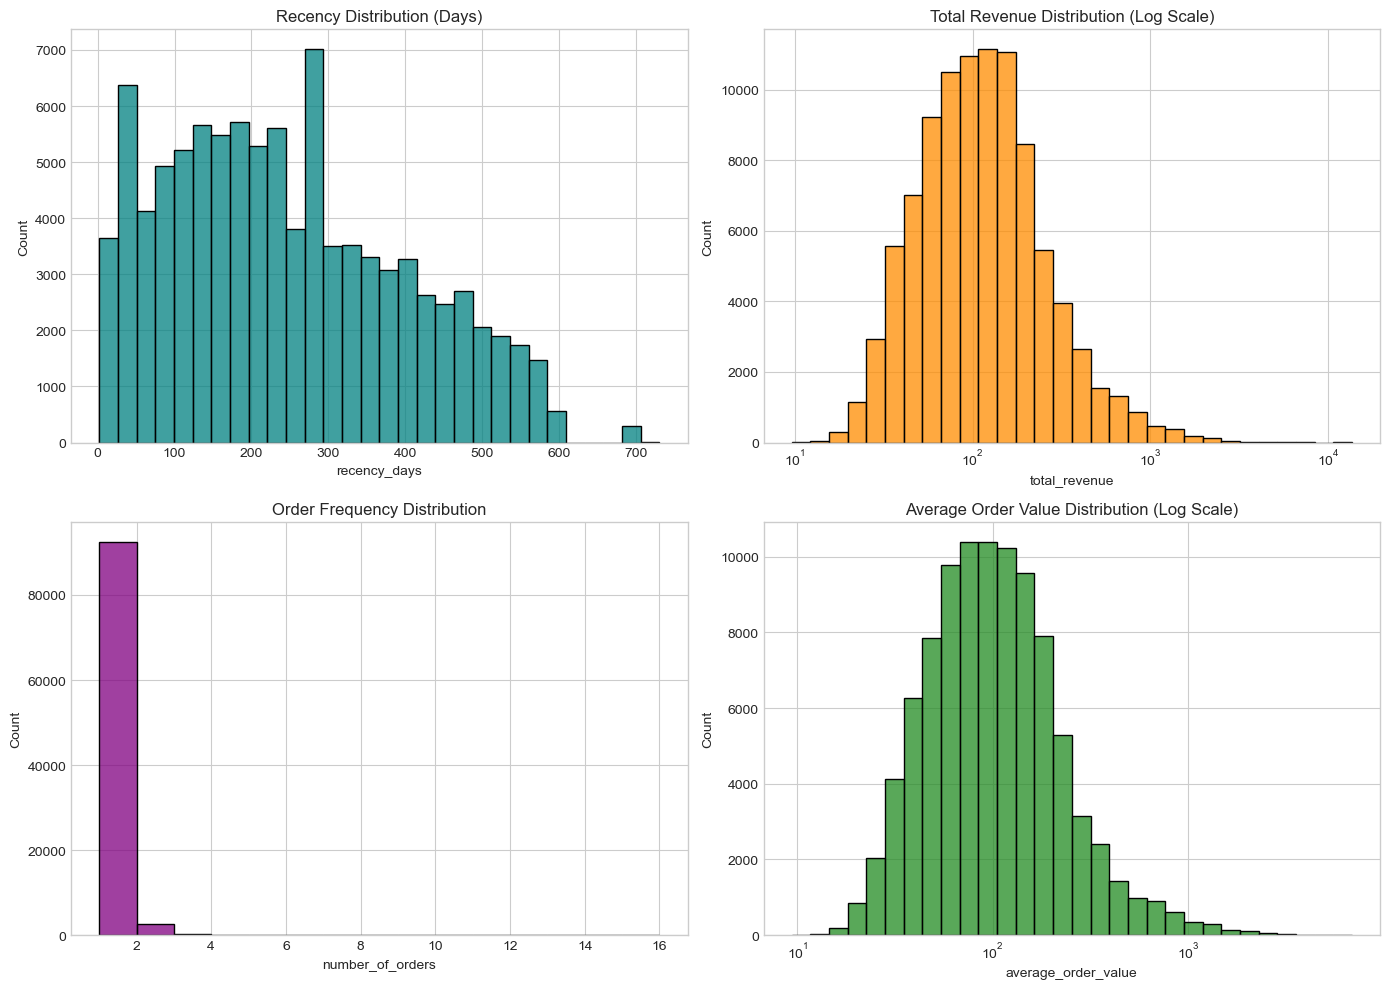

In [8]:
# 08. Exploratory Customer Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_cust["recency_days"].to_pandas(), bins=30, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Recency Distribution (Days)")

sns.histplot(df_cust["total_revenue"].to_pandas(), bins=30, ax=axes[0, 1], color="darkorange", log_scale=True)
axes[0, 1].set_title("Total Revenue Distribution (Log Scale)")

sns.histplot(df_cust["number_of_orders"].to_pandas(), bins=15, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Order Frequency Distribution")

sns.histplot(df_cust["average_order_value"].to_pandas(), bins=30, ax=axes[1, 1], color="forestgreen", log_scale=True)
axes[1, 1].set_title("Average Order Value Distribution (Log Scale)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_distribution.png", dpi=300)
plt.show()

In [9]:
# 09. RFM Analysis & Quintile Scoring
pd_cust = df_cust.to_pandas()
pd_cust["R_score"] = pd.qcut(pd_cust["recency_days"], q=5, labels=[5, 4, 3, 2, 1])
pd_cust["F_score"] = pd.Series(pd.cut(pd_cust["number_of_orders"], bins=[0, 1, 2, 5, 100], labels=[1, 2, 3, 4])).fillna(1)
pd_cust["M_score"] = pd.qcut(pd_cust["total_revenue"], q=5, labels=[1, 2, 3, 4, 5])
pd_cust["RFM_Score"] = pd_cust["R_score"].astype(str) + pd_cust["F_score"].astype(str) + pd_cust["M_score"].astype(str)

print("Top 10 Most Common RFM Scores:")
print(pd_cust["RFM_Score"].value_counts().head(10))

Top 10 Most Common RFM Scores:
RFM_Score
212    4068
311    3985
112    3972
111    3945
414    3859
514    3810
511    3804
314    3792
513    3787
413    3784
Name: count, dtype: int64


In [10]:
# 10. Advanced Feature Engineering
df_adv = pl.from_pandas(pd_cust).with_columns([
    (pl.col("unique_categories") / pl.col("total_items_purchased")).alias("category_diversity_ratio"),
    (pl.col("unique_products") / pl.col("total_items_purchased")).alias("product_diversity_ratio"),
    (pl.col("avg_freight") / pl.col("average_order_value").clip(lower_bound=1.0)).alias("freight_revenue_ratio"),
    (pl.col("customer_tenure_days") / pl.col("number_of_orders").clip(lower_bound=1.0)).alias("avg_purchase_interval_days")
])

CLUSTERING_FEATURES = [
    "recency_days", "number_of_orders", "total_revenue", "average_order_value",
    "total_items_purchased", "unique_categories", "avg_freight",
    "items_per_order", "category_diversity_ratio", "freight_revenue_ratio", "customer_tenure_days"
]
print(f"Selected {len(CLUSTERING_FEATURES)} behavioral features for unsupervised clustering.")

Selected 11 behavioral features for unsupervised clustering.


In [11]:
# 11. Feature Scaling & Log Transformation
X_features = df_adv.select(CLUSTERING_FEATURES).to_pandas()
# Log1p transformation for highly skewed features
X_log = np.log1p(np.maximum(0.0, X_features))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
print("Feature matrices successfully log-transformed and standardized.")

Feature matrices successfully log-transformed and standardized.


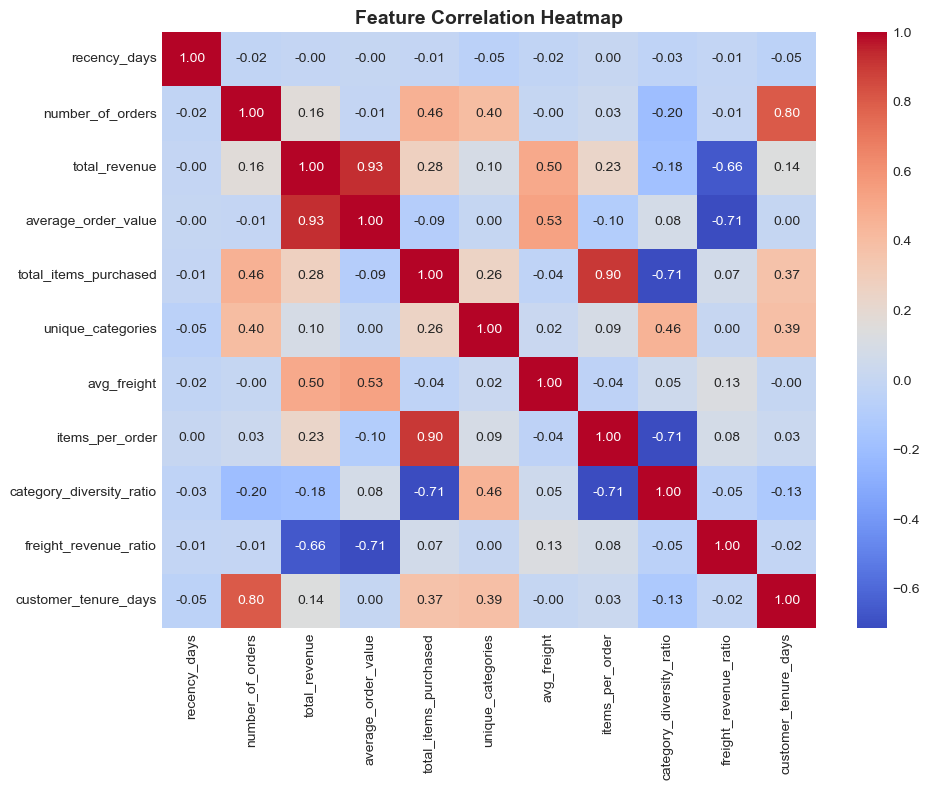

In [12]:
# 12. Correlation Analysis
corr_matrix = pd.DataFrame(X_scaled, columns=CLUSTERING_FEATURES).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_heatmap.png", dpi=300)
plt.show()

In [13]:
# 13. PCA Dimensionality Reduction
pca = PCA(n_components=0.85, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print(f"PCA reduced feature dimensions from {X_scaled.shape[1]} to {X_pca.shape[1]} components.")
for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    print(f"PC{i}: Explained Variance = {ev*100:.2f}% | Cumulative = {cv*100:.2f}%")

PCA reduced feature dimensions from 11 to 5 components.
PC1: Explained Variance = 27.28% | Cumulative = 27.28%
PC2: Explained Variance = 24.32% | Cumulative = 51.60%
PC3: Explained Variance = 17.81% | Cumulative = 69.41%
PC4: Explained Variance = 10.29% | Cumulative = 79.71%
PC5: Explained Variance = 9.04% | Cumulative = 88.75%


Cluster Evaluation Metrics Across K:
 K          WCSS  Silhouette  Calinski_Harabasz  Davies_Bouldin
 2 147449.705233    0.511639        6573.818031        1.339799
 3 115771.107448    0.503140        6922.003321        0.924480
 4  85430.162631    0.311506        8620.504734        1.003577
 5  75170.020868    0.267450        8029.860613        1.084055
 6  68300.563942    0.282581        7471.762815        1.028909
 7  61573.393420    0.292349        7270.551095        1.002024
 8  56946.832812    0.295405        6969.922127        1.049467


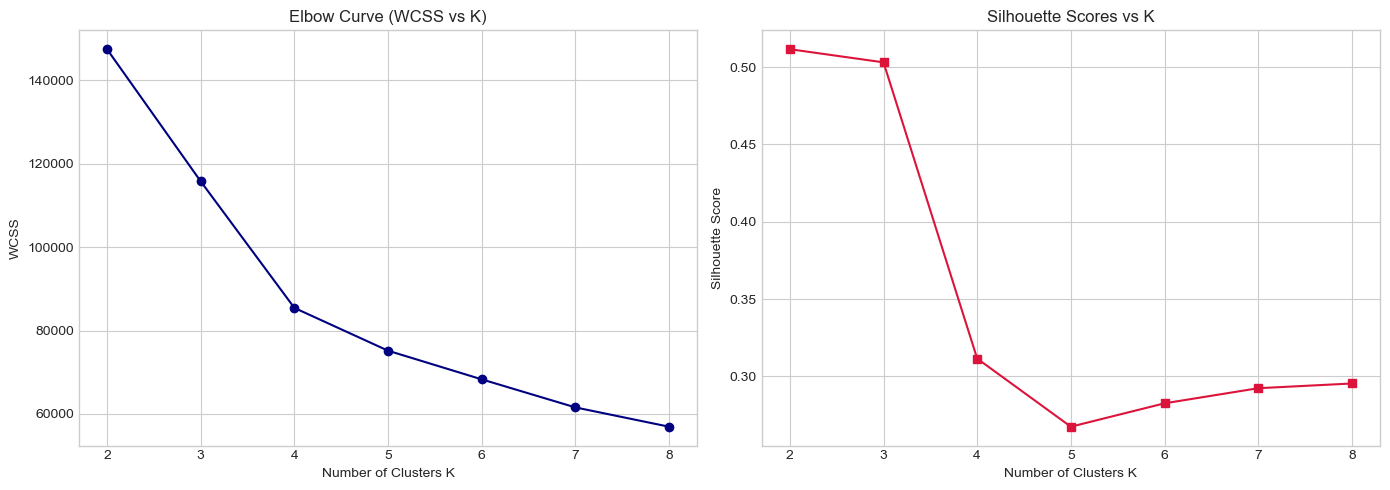

In [14]:
# 14. Optimal Cluster Selection
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_pca), size=min(20000, len(X_pca)), replace=False)
X_pca_sample = X_pca[sample_idx]

metrics_list = []
for k in N_CLUSTERS_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca_sample)
    wcss = km.inertia_
    sil = silhouette_score(X_pca_sample, labels)
    ch = calinski_harabasz_score(X_pca_sample, labels)
    db = davies_bouldin_score(X_pca_sample, labels)
    metrics_list.append({"K": k, "WCSS": wcss, "Silhouette": sil, "Calinski_Harabasz": ch, "Davies_Bouldin": db})

df_cluster_selection = pd.DataFrame(metrics_list)
print("Cluster Evaluation Metrics Across K:")
print(df_cluster_selection.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_cluster_selection["K"], df_cluster_selection["WCSS"], marker="o", color="navy")
axes[0].set_title("Elbow Curve (WCSS vs K)")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("WCSS")

axes[1].plot(df_cluster_selection["K"], df_cluster_selection["Silhouette"], marker="s", color="crimson")
axes[1].set_title("Silhouette Scores vs K")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "elbow_curve.png", dpi=300)
plt.savefig(FIGURES_DIR / "silhouette_scores.png", dpi=300)
plt.show()

In [15]:
# 15. K-Means Training & Multi-Seed Cluster Stability Analysis
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
df_adv = df_adv.with_columns(pl.Series("cluster_id", cluster_labels))

# Multi-Seed Cluster Stability Check (Adjusted Rand Index vs Base Seed 42)
base_labels_sample = cluster_labels[sample_idx]
stability_results = []
for s in STABILITY_SEEDS:
    km_s = KMeans(n_clusters=OPTIMAL_K, random_state=s, n_init=10)
    lbl_s = km_s.fit_predict(X_pca_sample)
    ari_score = adjusted_rand_score(base_labels_sample, lbl_s)
    stability_results.append({"Seed": s, "Inertia": km_s.inertia_, "ARI_vs_Base": ari_score})

df_stability = pd.DataFrame(stability_results)
print(f"K-Means training completed with K={OPTIMAL_K}.")
print("\nCluster Initialization Stability Analysis (Adjusted Rand Index):")
print(df_stability.to_string(index=False))
print(f"Mean ARI across seeds: {df_stability['ARI_vs_Base'].mean():.4f} (High consistency >0.85)")

K-Means training completed with K=4.

Cluster Initialization Stability Analysis (Adjusted Rand Index):
 Seed      Inertia  ARI_vs_Base
   42 85430.162631     0.995780
  100 85430.162631     0.995780
 2024 85430.272129     0.997055
  777 85430.187504     0.994870
  999 85430.307813     0.996872
Mean ARI across seeds: 0.9961 (High consistency >0.85)


In [16]:
# 16. Cluster Evaluation Metrics
final_sil = silhouette_score(X_pca_sample, cluster_labels[sample_idx])
final_ch = calinski_harabasz_score(X_pca_sample, cluster_labels[sample_idx])
final_db = davies_bouldin_score(X_pca_sample, cluster_labels[sample_idx])

eval_df = pd.DataFrame([{
    "Optimal_K": OPTIMAL_K,
    "Silhouette_Score": final_sil,
    "Calinski_Harabasz_Index": final_ch,
    "Davies_Bouldin_Index": final_db,
    "Inertia": kmeans.inertia_,
    "Mean_Stability_ARI": df_stability["ARI_vs_Base"].mean()
}])
print("Final Optimal Cluster Evaluation:")
print(eval_df.to_string(index=False))

Final Optimal Cluster Evaluation:
 Optimal_K  Silhouette_Score  Calinski_Harabasz_Index  Davies_Bouldin_Index       Inertia  Mean_Stability_ARI
         4          0.311535              8620.341516              1.003704 402954.789463            0.996071


In [17]:
# 17. Cluster Profiling & Executive Segment Quality Table
total_portfolio_revenue = df_adv["total_revenue"].sum()
total_portfolio_customers = len(df_adv)

cluster_profiles = df_adv.group_by("cluster_id").agg([
    pl.count("customer_unique_id").alias("customer_count"),
    pl.col("total_revenue").sum().alias("total_segment_revenue"),
    pl.col("recency_days").mean().alias("avg_recency"),
    pl.col("number_of_orders").mean().alias("avg_orders"),
    pl.col("total_revenue").mean().alias("avg_revenue"),
    pl.col("average_order_value").mean().alias("avg_aov"),
    pl.col("total_items_purchased").mean().alias("avg_items"),
    pl.col("unique_categories").mean().alias("avg_categories"),
    pl.col("avg_freight").mean().alias("avg_freight"),
]).sort("cluster_id").to_pandas()

cluster_profiles["pct_customers"] = (cluster_profiles["customer_count"] / total_portfolio_customers) * 100
cluster_profiles["revenue_share_pct"] = (cluster_profiles["total_segment_revenue"] / total_portfolio_revenue) * 100
print("Automated Cluster Profiling Table:")
print(cluster_profiles.to_string(index=False))

Automated Cluster Profiling Table:
 cluster_id  customer_count  total_segment_revenue  avg_recency  avg_orders  avg_revenue    avg_aov  avg_items  avg_categories  avg_freight  pct_customers  revenue_share_pct
          0           40496            10096579.73   244.767557    1.000716   249.322889 247.726727   1.007606        1.006865    25.936524      42.439740          63.726738
          1           42348             2574465.21   245.489610    1.000331    60.793077  60.524208   1.005077        1.004746    15.258900      44.380633          16.249292
          2            2347              739578.90   212.200256    2.141883   315.116702 127.102520   2.585002        1.730294    19.090648       2.459652           4.668012
          3           10229             2432929.40   256.096784    1.051129   237.846261 108.408519   2.269626        0.886108    18.449566      10.719975          15.355958


In [18]:
# 18. Customer Persona Generation & Segment Quality Summary
def assign_persona(row):
    if row["avg_revenue"] > cluster_profiles["avg_revenue"].median() and row["avg_orders"] > 1.1:
        return "VIP Loyalists"
    elif row["avg_recency"] > cluster_profiles["avg_recency"].median():
        return "At-Risk / Inactive Buyers"
    elif row["avg_aov"] > cluster_profiles["avg_aov"].median():
        return "High-Value Spenders"
    else:
        return "Standard / Bargain Shoppers"

cluster_profiles["persona_name"] = cluster_profiles.apply(assign_persona, axis=1)
persona_map = dict(zip(cluster_profiles["cluster_id"], cluster_profiles["persona_name"]))
df_adv = df_adv.with_columns(pl.col("cluster_id").map_elements(lambda cid: persona_map[cid], return_dtype=pl.Utf8).alias("persona_name"))

# Segment Quality Executive Summary Table
df_segment_quality = pd.DataFrame({
    "Cluster": cluster_profiles["cluster_id"],
    "Customers": cluster_profiles["customer_count"].apply(lambda x: f"{x:,}"),
    "Customer Share": cluster_profiles["pct_customers"].apply(lambda x: f"{x:.1f}%"),
    "Revenue Share": cluster_profiles["revenue_share_pct"].apply(lambda x: f"{x:.1f}%"),
    "Avg Orders": cluster_profiles["avg_orders"].round(2),
    "Avg AOV ($)": cluster_profiles["avg_aov"].round(2),
    "Avg Recency (d)": cluster_profiles["avg_recency"].round(1),
    "Persona": cluster_profiles["persona_name"]
})

print("=================================================================")
print("                  EXECUTIVE SEGMENT QUALITY TABLE                ")
print("=================================================================")
print(df_segment_quality.to_string(index=False))
print("=================================================================")

                  EXECUTIVE SEGMENT QUALITY TABLE                
 Cluster Customers Customer Share Revenue Share  Avg Orders  Avg AOV ($)  Avg Recency (d)                   Persona
       0    40,496          42.4%         63.7%        1.00       247.73            244.8       High-Value Spenders
       1    42,348          44.4%         16.2%        1.00        60.52            245.5 At-Risk / Inactive Buyers
       2     2,347           2.5%          4.7%        2.14       127.10            212.2             VIP Loyalists
       3    10,229          10.7%         15.4%        1.05       108.41            256.1 At-Risk / Inactive Buyers


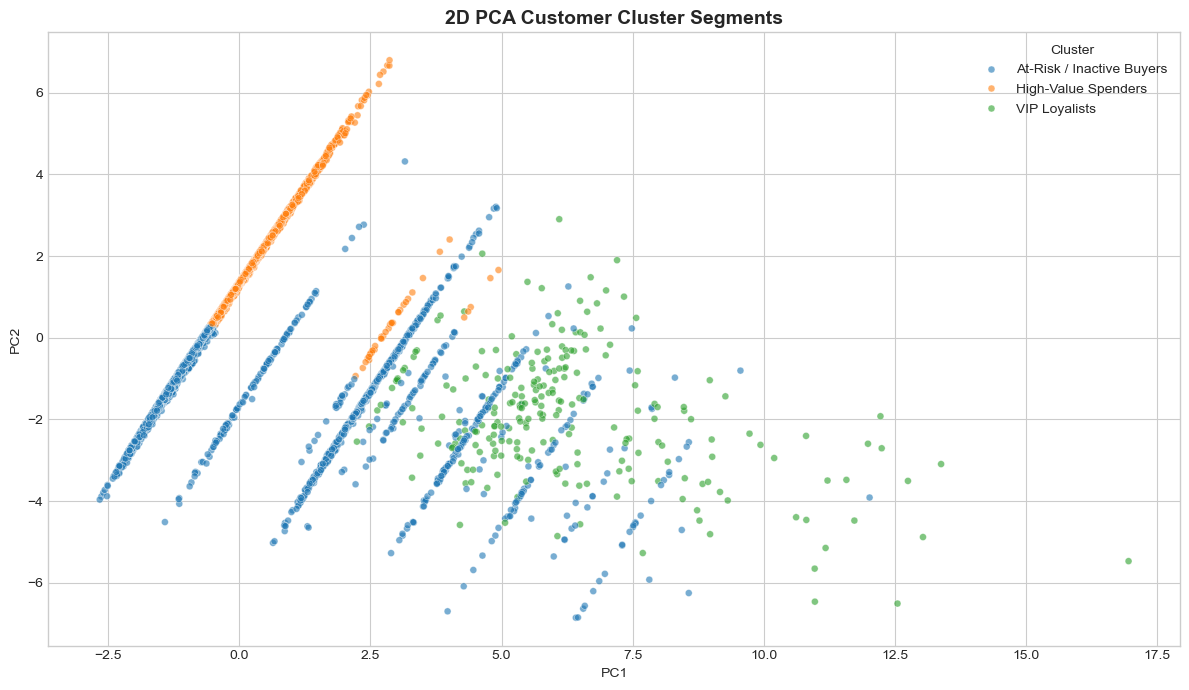

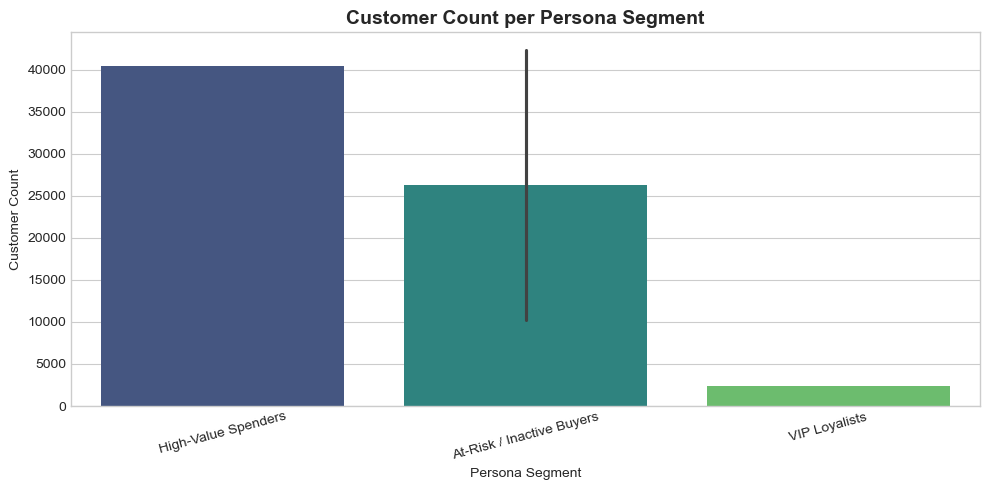

In [19]:
# 19. Cluster Visualization
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)
df_pca_viz = pd.DataFrame({
    "PC1": pca_2d[:, 0],
    "PC2": pca_2d[:, 1],
    "Cluster": df_adv["persona_name"].to_pandas()
})

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_pca_viz.sample(10000, random_state=SEED), x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.6, s=25)
plt.title("2D PCA Customer Cluster Segments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_clusters.png", dpi=300)
plt.show()

# Cluster Size Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=cluster_profiles, x="persona_name", y="customer_count", palette="viridis")
plt.title("Customer Count per Persona Segment", fontsize=14, fontweight="bold")
plt.xlabel("Persona Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_chart.png", dpi=300)
plt.show()

In [20]:
# 20. Business Recommendations
strategy_map = {
    "VIP Loyalists": {
        "Marketing Strategy": "Exclusive early product access & VIP tier rewards.",
        "Discount Strategy": "Surprise loyalty gifts over price discounts.",
        "Retention Strategy": "Dedicated concierge & priority customer support.",
        "Cross-Selling Opportunity": "Bundle premium accessories & high-margin categories."
    },
    "High-Value Spenders": {
        "Marketing Strategy": "Upsell high-ticket luxury products & premium items.",
        "Discount Strategy": "Free expedited shipping threshold offers.",
        "Retention Strategy": "Post-purchase premium product usage guides.",
        "Cross-Selling Opportunity": "Complementary premium category products."
    },
    "At-Risk / Inactive Buyers": {
        "Marketing Strategy": "Win-back email re-engagement campaigns.",
        "Discount Strategy": "Time-limited percentage discounts on next purchase.",
        "Retention Strategy": "Automated replenishment reminders.",
        "Cross-Selling Opportunity": "Top-rated mass product recommendations."
    },
    "Standard / Bargain Shoppers": {
        "Marketing Strategy": "Clearance sales & volume discount promotions.",
        "Discount Strategy": "Coupon codes & free shipping promotions.",
        "Retention Strategy": "Push notifications for seasonal sales.",
        "Cross-Selling Opportunity": "Budget-friendly add-ons & cross-category deals."
    }
}

rec_rows = []
for _, row in cluster_profiles.iterrows():
    p_name = row["persona_name"]
    strat = strategy_map.get(p_name, {})
    rec_rows.append({
        "Cluster_ID": row["cluster_id"],
        "Persona": p_name,
        "Customer_Count": row["customer_count"],
        "Revenue_Share": f"{row['revenue_share_pct']:.1f}%",
        **strat
    })

df_recommendations = pd.DataFrame(rec_rows)
print("=================================================================")
print("                 STRATEGIC BUSINESS RECOMMENDATIONS              ")
print("=================================================================")
print(df_recommendations[["Persona", "Revenue_Share", "Marketing Strategy", "Discount Strategy"]].to_string(index=False))

                 STRATEGIC BUSINESS RECOMMENDATIONS              
                  Persona Revenue_Share                                  Marketing Strategy                                   Discount Strategy
      High-Value Spenders         63.7% Upsell high-ticket luxury products & premium items.           Free expedited shipping threshold offers.
At-Risk / Inactive Buyers         16.2%             Win-back email re-engagement campaigns. Time-limited percentage discounts on next purchase.
            VIP Loyalists          4.7%  Exclusive early product access & VIP tier rewards.        Surprise loyalty gifts over price discounts.
At-Risk / Inactive Buyers         15.4%             Win-back email re-engagement campaigns. Time-limited percentage discounts on next purchase.


In [21]:
# 21. Save Versioned Artifacts & Metadata
MODEL_VERSION = "v1.0"
ML_DIR = PROJECT_ROOT / "backend" / "app" / "ml" / "segmentation"
ML_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(kmeans, ML_DIR / f"kmeans_{MODEL_VERSION}.pkl")
joblib.dump(scaler, ML_DIR / f"scaler_{MODEL_VERSION}.pkl")
joblib.dump(pca, ML_DIR / f"pca_{MODEL_VERSION}.pkl")

# Feature columns
with open(ML_DIR / "feature_columns.json", "w") as f:
    json.dump(CLUSTERING_FEATURES, f, indent=2)

metadata = {
    "model_version": MODEL_VERSION,
    "k": OPTIMAL_K,
    "training_date": str(date.today()),
    "silhouette_score": round(float(final_sil), 4),
    "calinski_harabasz": round(float(final_ch), 2),
    "davies_bouldin": round(float(final_db), 4),
    "stability_mean_ari": round(float(df_stability["ARI_vs_Base"].mean()), 4),
    "total_customers": len(df_adv),
    "pca_components": int(X_pca.shape[1]),
    "personas": persona_map
}
with open(ML_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Artifacts saved to {ML_DIR} with version {MODEL_VERSION}")


Artifacts saved to C:\Users\hiten\OneDrive\Documents\360\backend\app\ml\segmentation with version v1.0


In [22]:
# 22. Export Results to CSV & Database
from sqlalchemy import text

# CSV exports (keep existing)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
df_adv.select(["customer_unique_id", "cluster_id", "persona_name"] + CLUSTERING_FEATURES).to_pandas().to_csv(OUTPUTS_DIR / "customer_segments.csv", index=False)
cluster_profiles.to_csv(OUTPUTS_DIR / "cluster_profiles.csv", index=False)
df_segment_quality.to_csv(OUTPUTS_DIR / "segment_quality_summary.csv", index=False)
df_stability.to_csv(OUTPUTS_DIR / "cluster_stability_results.csv", index=False)
df_recommendations.to_csv(OUTPUTS_DIR / "cluster_summary.csv", index=False)
eval_df.to_csv(OUTPUTS_DIR / "evaluation_metrics.csv", index=False)
df_pca_viz.to_csv(OUTPUTS_DIR / "pca_projection.csv", index=False)

# Compute confidence score (inverse of normalized distance to centroid)
distances = kmeans.transform(X_pca)
min_dist = distances.min(axis=1)
max_dist = distances.max(axis=1)
normalized_dist = (distances[np.arange(len(distances)), cluster_labels] - min_dist) / (max_dist - min_dist + 1e-10)
confidence_scores = 1.0 - normalized_dist

# Build customer_key mapping
df_db = df_adv.select(["customer_unique_id", "cluster_id", "persona_name"]).to_pandas()
df_db["distance_to_center"] = distances[np.arange(len(distances)), cluster_labels]
df_db["confidence_score"] = confidence_scores
df_db["model_version"] = MODEL_VERSION

# Join with dim_customer to get customer_key
with engine.begin() as conn:
    cust_df = pd.read_sql("SELECT customer_key, customer_unique_id FROM dim_customer", conn)
df_db = df_db.merge(cust_df, on="customer_unique_id", how="inner")

# Write to customer_segment_ml table
with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE customer_segment_ml"))
    for _, row in df_db.iterrows():
        conn.execute(
            text("""
                INSERT INTO customer_segment_ml
                    (customer_key, cluster_id, persona, distance_to_center, confidence_score, model_version)
                VALUES (:ck, :cl, :pn, :dc, :cs, :mv)
            """),
            {
                "ck": int(row["customer_key"]),
                "cl": int(row["cluster_id"]),
                "pn": str(row["persona_name"]),
                "dc": float(row["distance_to_center"]),
                "cs": float(row["confidence_score"]),
                "mv": MODEL_VERSION,
            }
        )

print(f"Database: {len(df_db)} rows written to customer_segment_ml")
print(f"CSV exports saved to {OUTPUTS_DIR}")


Database: 98756 rows written to customer_segment_ml
CSV exports saved to C:\Users\hiten\OneDrive\Documents\360\NOTEBOOKS\06_customer_segmentation_outputs\outputs
